In [11]:
import re
import string
from collections import Counter, defaultdict

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from textblob import TextBlob
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer


In [12]:
for resource in ["punkt", "stopwords", "wordnet", "averaged_perceptron_tagger",
                  "punkt_tab", "omw-1.4"]:
    try:
        nltk.download(resource, quiet=True)
    except Exception:
        pass

In [13]:
RAW_REVIEWS = [
    {"id": 1,  "source": "Zomato",        "rating": 5, "text": "The biryani was absolutely delicious and arrived piping hot! Delivery was super fast too. Will definitely order again."},
    {"id": 2,  "source": "Swiggy",        "rating": 1, "text": "Waited over an hour for my order. The food was cold and completely unacceptable. Very disappointed."},
    {"id": 3,  "source": "Google",        "rating": 3, "text": "Decent food but the packaging was terrible. Everything was leaking by the time it arrived. Fix your packaging!"},
    {"id": 4,  "source": "Feedback form", "rating": 5, "text": "Amazing customer service! They called to check if everything was okay. Will definitely order again!"},
    {"id": 5,  "source": "Google",        "rating": 2, "text": "The price has gone up but the portion size is smaller now. Not worth it anymore. Very overpriced for what you get."},
    {"id": 6,  "source": "Zomato",        "rating": 5, "text": "Food tastes fresh and authentic. The naan was perfectly cooked. Highly recommend this restaurant to everyone!"},
    {"id": 7,  "source": "Feedback form", "rating": 1, "text": "The delivery person was very rude. I complained to customer support but nobody responded. Terrible experience overall."},
    {"id": 8,  "source": "Swiggy",        "rating": 3, "text": "Average meal. Nothing special. Took about 45 minutes which was okay I guess. Food was neither great nor bad."},
    {"id": 9,  "source": "Google",        "rating": 2, "text": "The paneer butter masala was bland and tasteless. Expected much better quality for this price point. Very let down."},
    {"id": 10, "source": "Zomato",        "rating": 4, "text": "Order was missing two items. Contacted support and they resolved it quickly with a full refund. Appreciated the quick help."},
    {"id": 11, "source": "Swiggy",        "rating": 5, "text": "Best butter chicken I have had in months! Arrived hot, packaging was neat and secure. Highly satisfied customer!"},
    {"id": 12, "source": "Google",        "rating": 1, "text": "Extremely slow delivery. Food arrived after 90 minutes and was completely cold. The restaurant did not even apologize."},
    {"id": 13, "source": "Feedback form", "rating": 4, "text": "Good food and reasonable pricing. The garlic naan was crispy and delicious. Minor delay in delivery but overall a great experience."},
    {"id": 14, "source": "Zomato",        "rating": 2, "text": "The dal makhani was watery and lacked flavour. Packaging was fine but the food quality has definitely gone downhill."},
    {"id": 15, "source": "Swiggy",        "rating": 5, "text": "Excellent service! Order was accurate, food was fresh and tasty, and delivery was on time. Perfect experience from start to finish."},
]


def load_data() -> pd.DataFrame:
    """Task 1: Load reviews into a DataFrame."""
    df = pd.DataFrame(RAW_REVIEWS)
    print("=" * 60)
    print("TASK 1 — DATA COLLECTION")
    print("=" * 60)
    print(f"  Total reviews loaded : {len(df)}")
    print(f"  Sources              : {', '.join(df['source'].unique())}")
    print(f"  Rating range         : {df['rating'].min()} – {df['rating'].max()}")
    print()
    return df



In [14]:
stemmer    = PorterStemmer()
lemmatizer = WordNetLemmatizer()
STOP_WORDS = set(stopwords.words("english"))


def clean_text(text: str) -> str:
    """Lowercase, remove punctuation, digits, and extra spaces."""
    text = text.lower()
    text = re.sub(r"https?://\S+|www\.\S+", "", text)   # URLs
    text = re.sub(r"[^a-z\s]", " ", text)               # non-alpha
    text = re.sub(r"\s+", " ", text).strip()
    return text


def tokenize(text: str) -> list:
    return word_tokenize(text)


def remove_stopwords(tokens: list) -> list:
    return [t for t in tokens if t not in STOP_WORDS and len(t) > 1]


def stem_tokens(tokens: list) -> list:
    return [stemmer.stem(t) for t in tokens]


def lemmatize_tokens(tokens: list) -> list:
    return [lemmatizer.lemmatize(t) for t in tokens]


def preprocess(text: str) -> dict:
    """Full preprocessing pipeline for a single review."""
    cleaned   = clean_text(text)
    tokens    = tokenize(cleaned)
    no_stop   = remove_stopwords(tokens)
    stemmed   = stem_tokens(no_stop)
    lemmatized = lemmatize_tokens(no_stop)
    return {
        "cleaned"   : cleaned,
        "tokens"    : tokens,
        "no_stop"   : no_stop,
        "stemmed"   : stemmed,
        "lemmatized": lemmatized,
        "processed_text": " ".join(lemmatized),
    }


def preprocess_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """Task 2: Apply preprocessing to every review."""
    print("=" * 60)
    print("TASK 2 — TEXT PREPROCESSING")
    print("=" * 60)

    results = df["text"].apply(preprocess)
    df = df.copy()
    df["cleaned"]        = results.apply(lambda r: r["cleaned"])
    df["tokens"]         = results.apply(lambda r: r["tokens"])
    df["no_stop"]        = results.apply(lambda r: r["no_stop"])
    df["stemmed"]        = results.apply(lambda r: r["stemmed"])
    df["lemmatized"]     = results.apply(lambda r: r["lemmatized"])
    df["processed_text"] = results.apply(lambda r: r["processed_text"])

    print("  Pipeline: clean → tokenize → stop-word removal → stemming → lemmatization")
    print(f"  Avg tokens (raw)      : {df['tokens'].apply(len).mean():.1f}")
    print(f"  Avg tokens (no-stop)  : {df['no_stop'].apply(len).mean():.1f}")
    print()

    # Sample output
    sample = df.iloc[0]
    print(f"  Sample review #{sample['id']}:")
    print(f"    Original  : {sample['text'][:70]}…")
    print(f"    Cleaned   : {sample['cleaned'][:70]}…")
    print(f"    Tokens    : {sample['tokens'][:8]}")
    print(f"    No-stop   : {sample['no_stop'][:8]}")
    print(f"    Lemmatized: {sample['lemmatized'][:8]}")
    print()
    return df


In [15]:
def classify_sentiment(text: str) -> dict:
    """
    TextBlob polarity-based classification.
    polarity: -1 (most negative) … +1 (most positive)
    """
    blob = TextBlob(text)
    polarity     = round(blob.sentiment.polarity, 3)
    subjectivity = round(blob.sentiment.subjectivity, 3)

    if polarity > 0.1:
        label = "Positive"
    elif polarity < -0.1:
        label = "Negative"
    else:
        label = "Neutral"

    confidence = round(min(abs(polarity) * 100 + 40, 99), 1)
    return {
        "polarity"    : polarity,
        "subjectivity": subjectivity,
        "sentiment"   : label,
        "confidence"  : confidence,
    }


def run_sentiment(df: pd.DataFrame) -> pd.DataFrame:
    """Task 3: Classify sentiment for every review."""
    print("=" * 60)
    print("TASK 3 — SENTIMENT CLASSIFICATION")
    print("=" * 60)

    sent = df["text"].apply(classify_sentiment).apply(pd.Series)
    df   = pd.concat([df, sent], axis=1)

    counts = df["sentiment"].value_counts()
    for label, cnt in counts.items():
        pct = cnt / len(df) * 100
        print(f"  {label:10s}: {cnt:3d} reviews  ({pct:.0f}%)")
    print()

    print(f"  {'ID':>3}  {'Source':15}  {'Rating'}  {'Sentiment':10}  {'Polarity':>8}  {'Conf':>6}")
    print("  " + "-" * 60)
    for _, row in df.iterrows():
        print(f"  {row['id']:>3}  {row['source']:15}  {row['rating']:>6}  "
              f"{row['sentiment']:10}  {row['polarity']:>8.3f}  {row['confidence']:>5.1f}%")
    print()
    return df


In [16]:
ISSUE_KEYWORDS = {
    "Delivery speed":   ["slow", "wait", "waited", "hour", "delay", "late", "minutes", "long", "fast", "quick"],
    "Food quality":     ["bland", "cold", "hot", "fresh", "tasty", "delicious", "tasteless", "watery", "flavour",
                         "authentic", "overcooked", "stale", "quality"],
    "Packaging":        ["leaking", "packaging", "packed", "damaged", "broken", "spill", "secure", "neat"],
    "Pricing":          ["price", "priced", "expensive", "worth", "cost", "overpriced", "portion", "value",
                         "reasonable", "pricing"],
    "Customer service": ["rude", "support", "service", "complaint", "complained", "responded", "resolved",
                         "refund", "apologize", "called"],
    "Order accuracy":   ["missing", "wrong", "incorrect", "item", "extra", "accurate", "order"],
}


def detect_issues(text: str) -> list:
    lower = text.lower()
    return [cat for cat, kws in ISSUE_KEYWORDS.items() if any(k in lower for k in kws)]


def run_issue_detection(df: pd.DataFrame) -> pd.DataFrame:
    """Task 4: Flag service issues in each review."""
    print("=" * 60)
    print("TASK 4 — COMMON SERVICE ISSUE DETECTION")
    print("=" * 60)

    df = df.copy()
    df["issues"] = df["text"].apply(detect_issues)

    # Count per category
    all_issues = [issue for issues in df["issues"] for issue in issues]
    issue_counts = Counter(all_issues)

    print(f"  {'Category':22}  {'Count':>5}  {'Mentions':>8}")
    print("  " + "-" * 42)
    for cat, cnt in sorted(issue_counts.items(), key=lambda x: -x[1]):
        bar = "█" * cnt
        print(f"  {cat:22}  {cnt:>5}  {bar}")
    print()

    # TF-IDF top terms per sentiment group
    print("  Top TF-IDF terms by sentiment group:")
    tfidf = TfidfVectorizer(max_features=10, stop_words="english")
    for label in ["Positive", "Negative", "Neutral"]:
        group = df[df["sentiment"] == label]["processed_text"]
        if len(group) < 1:
            continue
        try:
            tfidf.fit_transform(group)
            terms = tfidf.get_feature_names_out()
            print(f"    {label}: {', '.join(terms)}")
        except Exception:
            pass
    print()
    return df



In [17]:
def generate_report(df: pd.DataFrame) -> None:
    """Task 5: Print a structured report and save charts."""
    print("=" * 60)
    print("TASK 5 — FEEDBACK ANALYSIS REPORT")
    print("=" * 60)

    total = len(df)
    pos   = (df["sentiment"] == "Positive").sum()
    neg   = (df["sentiment"] == "Negative").sum()
    neu   = (df["sentiment"] == "Neutral").sum()
    avg_r = df["rating"].mean()

    print(f"""
  ┌─────────────────────────────────────────────────┐
  │        RESTAURANT FEEDBACK ANALYSIS REPORT      │
  └─────────────────────────────────────────────────┘

  OVERVIEW
  ─────────────────────────────────────────────────
  Total reviews analysed : {total}
  Average star rating    : {avg_r:.2f} / 5.0

  SENTIMENT DISTRIBUTION
  ─────────────────────────────────────────────────
  Positive : {pos} reviews ({pos/total*100:.0f}%)
  Negative : {neg} reviews ({neg/total*100:.0f}%)
  Neutral  : {neu} reviews ({neu/total*100:.0f}%)
""")

    all_issues = [i for issues in df["issues"] for i in issues]
    issue_counts = Counter(all_issues)

    print("  TOP SERVICE ISSUES")
    print("  " + "─" * 49)
    for i, (cat, cnt) in enumerate(issue_counts.most_common(), 1):
        print(f"  {i}. {cat:22}  — mentioned in {cnt} review(s)")

    print()
    print("  POSITIVE HIGHLIGHTS")
    print("  " + "─" * 49)
    for _, row in df[df["sentiment"] == "Positive"].head(3).iterrows():
        print(f"  ★ \"{row['text'][:75]}…\"")

    print()
    print("  CRITICAL COMPLAINTS")
    print("  " + "─" * 49)
    for _, row in df[df["sentiment"] == "Negative"].head(3).iterrows():
        print(f"  ✗ \"{row['text'][:75]}…\"")

    print()
    print("  RECOMMENDATIONS")
    print("  " + "─" * 49)
    recs = [
        ("Delivery speed",   "Partner with more delivery agents during peak hours to reduce wait times."),
        ("Food quality",     "Introduce quality checks before dispatch; maintain temperature with insulated bags."),
        ("Packaging",        "Switch to leak-proof, compartmentalized containers for liquid-heavy dishes."),
        ("Pricing",          "Communicate value clearly; consider loyalty discounts for repeat customers."),
        ("Customer service", "Mandate <2-hour complaint response SLA; train delivery staff on etiquette."),
        ("Order accuracy",   "Introduce a double-check scan before sealing orders."),
    ]
    for cat, rec in recs:
        if cat in issue_counts:
            print(f"  → [{cat}] {rec}")

    print()
    _plot_charts(df, issue_counts)


def _plot_charts(df: pd.DataFrame, issue_counts: Counter) -> None:
    """Generate and save 4 analysis charts."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("Restaurant Feedback NLP Analysis", fontsize=16, fontweight="bold", y=1.01)

    colors_sent = {"Positive": "#639922", "Negative": "#E24B4A", "Neutral": "#888780"}

    # 1. Sentiment pie chart
    ax1 = axes[0, 0]
    sent_counts = df["sentiment"].value_counts()
    ax1.pie(
        sent_counts,
        labels=sent_counts.index,
        colors=[colors_sent[l] for l in sent_counts.index],
        autopct="%1.0f%%",
        startangle=90,
        wedgeprops={"linewidth": 1, "edgecolor": "white"},
    )
    ax1.set_title("Sentiment distribution", fontweight="bold")

    # 2. Issue bar chart
    ax2 = axes[0, 1]
    issues_sorted = issue_counts.most_common()
    cats, cnts = zip(*issues_sorted)
    bars = ax2.barh(cats, cnts, color="#378ADD", edgecolor="white", height=0.6)
    ax2.bar_label(bars, padding=3, fontsize=9)
    ax2.set_xlabel("Number of reviews")
    ax2.set_title("Common service issues", fontweight="bold")
    ax2.invert_yaxis()

    # 3. Rating distribution
    ax3 = axes[1, 0]
    rating_colors = {1: "#E24B4A", 2: "#D85A30", 3: "#BA7517", 4: "#639922", 5: "#1D9E75"}
    rating_counts = df["rating"].value_counts().sort_index()
    ax3.bar(
        rating_counts.index,
        rating_counts.values,
        color=[rating_colors[r] for r in rating_counts.index],
        edgecolor="white",
        width=0.6,
    )
    ax3.set_xlabel("Star rating")
    ax3.set_ylabel("Count")
    ax3.set_xticks([1, 2, 3, 4, 5])
    ax3.set_title("Rating distribution", fontweight="bold")

    # 4. Word cloud of all reviews
    ax4 = axes[1, 1]
    all_words = " ".join(df["processed_text"])
    wc = WordCloud(
        width=600, height=400,
        background_color="white",
        colormap="Blues",
        max_words=60,
        collocations=False,
    ).generate(all_words)
    ax4.imshow(wc, interpolation="bilinear")
    ax4.axis("off")
    ax4.set_title("Most frequent terms (word cloud)", fontweight="bold")

    plt.tight_layout()
    out_path = "feedback_analysis_report.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"  Charts saved → {out_path}")
    plt.show()



TASK 1 — DATA COLLECTION
  Total reviews loaded : 15
  Sources              : Zomato, Swiggy, Google, Feedback form
  Rating range         : 1 – 5

TASK 2 — TEXT PREPROCESSING
  Pipeline: clean → tokenize → stop-word removal → stemming → lemmatization
  Avg tokens (raw)      : 18.3
  Avg tokens (no-stop)  : 11.2

  Sample review #1:
    Original  : The biryani was absolutely delicious and arrived piping hot! Delivery …
    Cleaned   : the biryani was absolutely delicious and arrived piping hot delivery w…
    Tokens    : ['the', 'biryani', 'was', 'absolutely', 'delicious', 'and', 'arrived', 'piping']
    No-stop   : ['biryani', 'absolutely', 'delicious', 'arrived', 'piping', 'hot', 'delivery', 'super']
    Lemmatized: ['biryani', 'absolutely', 'delicious', 'arrived', 'piping', 'hot', 'delivery', 'super']

TASK 3 — SENTIMENT CLASSIFICATION
  Positive  :   9 reviews  (60%)
  Negative  :   4 reviews  (27%)
  Neutral   :   2 reviews  (13%)

   ID  Source           Rating  Sentiment   Polar

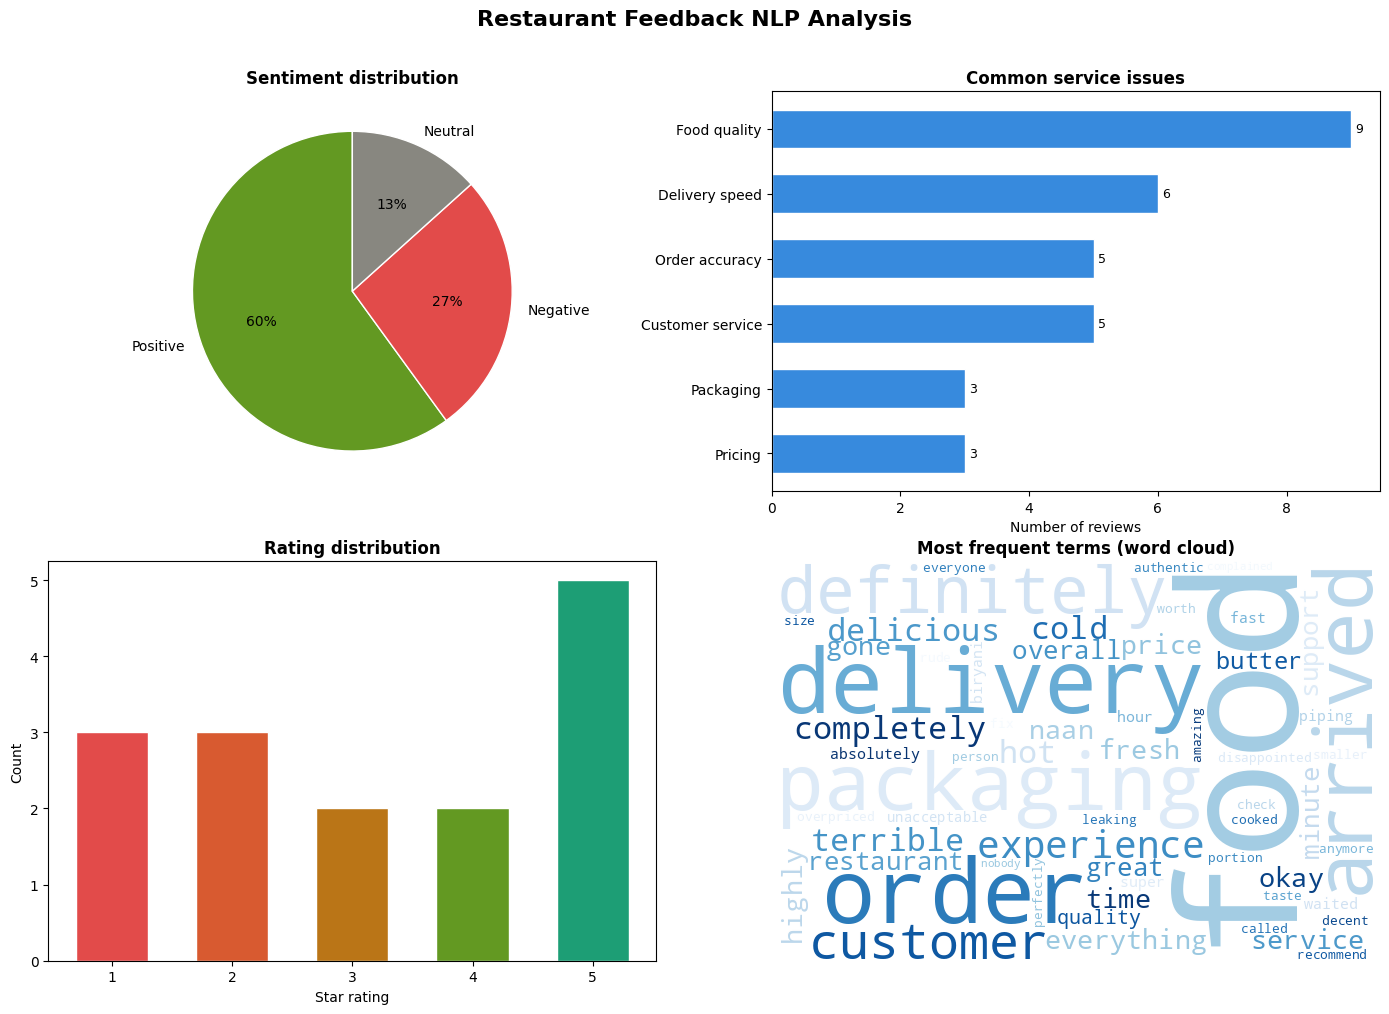

  Data saved → feedback_results.csv


In [10]:
def main():
    df = load_data()
    df = preprocess_dataframe(df)
    df = run_sentiment(df)
    df = run_issue_detection(df)
    generate_report(df)

    # Save processed data to CSV
    csv_cols = ["id", "source", "rating", "text", "sentiment", "polarity",
                "subjectivity", "confidence", "issues"]
    df[csv_cols].to_csv("feedback_results.csv", index=False)
    print("  Data saved → feedback_results.csv")


if __name__ == "__main__":
    main()